In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import SGDRegressor
import joblib

In [71]:
df = pd.read_csv("FINAL_USO.csv")

In [72]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,...,GDX_Low,GDX_Close,GDX_Adj Close,GDX_Volume,USO_Open,USO_High,USO_Low,USO_Close,USO_Adj Close,USO_Volume
0,2011-12-15,154.740005,154.949997,151.710007,152.330002,152.330002,21521900,123.029999,123.199997,121.989998,...,51.570000,51.680000,48.973877,20605600,36.900002,36.939999,36.049999,36.130001,36.130001,12616700
1,2011-12-16,154.309998,155.369995,153.899994,155.229996,155.229996,18124300,122.230003,122.949997,121.300003,...,52.040001,52.680000,49.921513,16285400,36.180000,36.500000,35.730000,36.270000,36.270000,12578800
2,2011-12-19,155.479996,155.860001,154.360001,154.869995,154.869995,12547200,122.059998,122.320000,120.029999,...,51.029999,51.169998,48.490578,15120200,36.389999,36.450001,35.930000,36.200001,36.200001,7418200
3,2011-12-20,156.820007,157.429993,156.580002,156.979996,156.979996,9136300,122.180000,124.139999,120.370003,...,52.369999,52.990002,50.215282,11644900,37.299999,37.610001,37.220001,37.560001,37.560001,10041600
4,2011-12-21,156.979996,157.529999,156.130005,157.160004,157.160004,11996100,123.930000,124.360001,122.750000,...,52.419998,52.959999,50.186852,8724300,37.669998,38.240002,37.520000,38.110001,38.110001,10728000


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1718 entries, 0 to 1717
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1718 non-null   object 
 1   Open           1718 non-null   float64
 2   High           1718 non-null   float64
 3   Low            1718 non-null   float64
 4   Close          1718 non-null   float64
 5   Adj Close      1718 non-null   float64
 6   Volume         1718 non-null   int64  
 7   SP_open        1718 non-null   float64
 8   SP_high        1718 non-null   float64
 9   SP_low         1718 non-null   float64
 10  SP_close       1718 non-null   float64
 11  SP_Ajclose     1718 non-null   float64
 12  SP_volume      1718 non-null   int64  
 13  DJ_open        1718 non-null   float64
 14  DJ_high        1718 non-null   float64
 15  DJ_low         1718 non-null   float64
 16  DJ_close       1718 non-null   float64
 17  DJ_Ajclose     1718 non-null   float64
 18  DJ_volum

In [74]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,SP_close,...,GDX_Low,GDX_Close,GDX_Adj Close,GDX_Volume,USO_Open,USO_High,USO_Low,USO_Close,USO_Adj Close,USO_Volume
count,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1.718000e+03,1718.000000,1718.000000,1718.000000,1718.000000,...,1718.000000,1718.000000,1718.000000,1.718000e+03,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1.718000e+03
mean,127.323434,127.854237,126.777695,127.319482,127.319482,8.446327e+06,204.490023,205.372637,203.487014,204.491222,...,26.384575,26.715012,25.924624,4.356515e+07,22.113417,22.307148,21.904657,22.109051,22.109051,1.922313e+07
std,17.526993,17.631189,17.396513,17.536269,17.536269,4.920731e+06,43.831928,43.974644,43.618940,43.776999,...,10.490908,10.603110,9.886570,2.909151e+07,11.431056,11.478671,11.373997,11.432787,11.432787,1.575743e+07
min,100.919998,100.989998,100.230003,100.500000,100.500000,1.501600e+06,122.059998,122.320000,120.029999,120.290001,...,12.400000,12.470000,12.269618,4.729000e+06,7.820000,8.030000,7.670000,7.960000,7.960000,1.035100e+06
25%,116.220001,116.540001,115.739998,116.052502,116.052502,5.412925e+06,170.392498,170.962506,169.577499,170.397500,...,20.355000,20.585000,20.180950,2.259968e+07,11.420000,11.500000,11.300000,11.392500,11.392500,6.229500e+06
50%,121.915001,122.325001,121.369999,121.795002,121.795002,7.483900e+06,205.464996,206.459999,204.430000,205.529999,...,22.870001,23.054999,22.677604,3.730465e+07,16.450000,16.635001,16.040000,16.345000,16.345000,1.613015e+07
75%,128.427494,129.087498,127.840001,128.470001,128.470001,1.020795e+07,237.292500,237.722500,236.147503,236.889996,...,26.797500,27.317500,26.478154,5.697055e+07,34.419998,34.667499,34.110000,34.417499,34.417499,2.672375e+07
max,173.199997,174.070007,172.919998,173.610001,173.610001,9.380420e+07,293.089996,293.940002,291.809998,293.579987,...,56.770000,57.470001,54.617039,2.321536e+08,41.599998,42.299999,41.299999,42.009998,42.009998,1.102657e+08


In [75]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [76]:
# Sort by date to maintain chronological order
df = df.sort_values('Date').reset_index(drop=True)

print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")


Date range: 2011-12-15 00:00:00 to 2018-12-31 00:00:00


In [77]:
# let's identify our target
target = "USO_Close"

In [78]:
# Columns we should NOT use as features (to avoid data leakage)
# These are current-day USO price data that would leak the target
leakage_columns = ['USO_Open','USO_High','USO_Low','USO_Adj Close','USO_Volume']

In [79]:
# Drop ambiguous unlabeled columns + trend columns (near-zero correlation)
ambiguous_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

# Drop Trend columns — binary 0/1 flags with near-zero correlation to target
trend_cols = [c for c in df.columns if 'Trend' in c]

print(f"Trend columns found: {trend_cols}")

columns_to_drop = ['Date'] + leakage_columns + ambiguous_cols + trend_cols

print(f"\nTotal columns to drop: {len(columns_to_drop)}")
print(columns_to_drop)


Trend columns found: ['EU_Trend', 'OF_Trend', 'OS_Trend', 'SF_Trend', 'USB_Trend', 'PLT_Trend', 'PLD_Trend', 'USDI_Trend']

Total columns to drop: 20
['Date', 'USO_Open', 'USO_High', 'USO_Low', 'USO_Adj Close', 'USO_Volume', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'EU_Trend', 'OF_Trend', 'OS_Trend', 'SF_Trend', 'USB_Trend', 'PLT_Trend', 'PLD_Trend', 'USDI_Trend']


In [80]:
# First, extract year from date
# so that Year, Month, DayOfWeek get included as features
df['Year']      = df['Date'].dt.year
df['Month']     = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek   # 0 = Monday, 4 = Friday

print("Time features added:")
print(df[['Date', 'Year', 'Month', 'DayOfWeek']].head())

Time features added:
        Date  Year  Month  DayOfWeek
0 2011-12-15  2011     12          3
1 2011-12-16  2011     12          4
2 2011-12-19  2011     12          0
3 2011-12-20  2011     12          1
4 2011-12-21  2011     12          2


In [81]:
# Create feature matrix X (all columns except target and leakage columns)
feature_columns = [col for col in df.columns if col not in columns_to_drop + [target]]
X = df[feature_columns].copy()
y = df[target].copy()

print(f"Number of features: {len(feature_columns)}")
print(f"Features: {feature_columns[:10]}...")


Number of features: 63
Features: ['SP_open', 'SP_high', 'SP_low', 'SP_close', 'SP_Ajclose', 'SP_volume', 'DJ_open', 'DJ_high', 'DJ_low', 'DJ_close']...


In [82]:
# Check for any remaining missing values
print("Missing values in features:")
print(X.isnull().sum().sum())

Missing values in features:
0


In [83]:
# Check for infinite values
print(f"Any infinite values? {np.isinf(X).any().any()}")

Any infinite values? False


# Step 3: Train-Test Split for Time Series

In [84]:
# Split into train (80%) and validation (20%)
# shuffle=True mixes all years so both sets see all price levels
# This is what fixes the negative R² — train and val now have similar distributions
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print()
print("--- Distribution check ---")
print(f"Train USO_Close mean: ${y_train.mean():.2f}")
print(f"Val   USO_Close mean: ${y_val.mean():.2f}")


X_train shape: (1374, 63)
X_val shape:   (344, 63)

--- Distribution check ---
Train USO_Close mean: $21.93
Val   USO_Close mean: $22.84


Step 4: Feature Standardization

In [85]:
# Initialize the scaler
scaler = StandardScaler()


In [86]:
# Fit the scaler on TRAINING data ONLY (to prevent data leakage)
# Then transform both training and validation/test data
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print("Scaling done.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape:   {X_val_scaled.shape}")

Scaling done.
X_train_scaled shape: (1374, 63)
X_val_scaled shape:   (344, 63)


In [87]:
# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=X_val.columns,   index=X_val.index)

print("After scaling:")
print(f"X_train_scaled mean: {X_train_scaled.mean().mean():.2f} (should be ~0)")
print(f"X_train_scaled std: {X_train_scaled.std().mean():.2f} (should be ~1)")

After scaling:
X_train_scaled mean: -0.00 (should be ~0)
X_train_scaled std: 1.00 (should be ~1)


Step 5: Exploratory Data Analysis - Visualizations

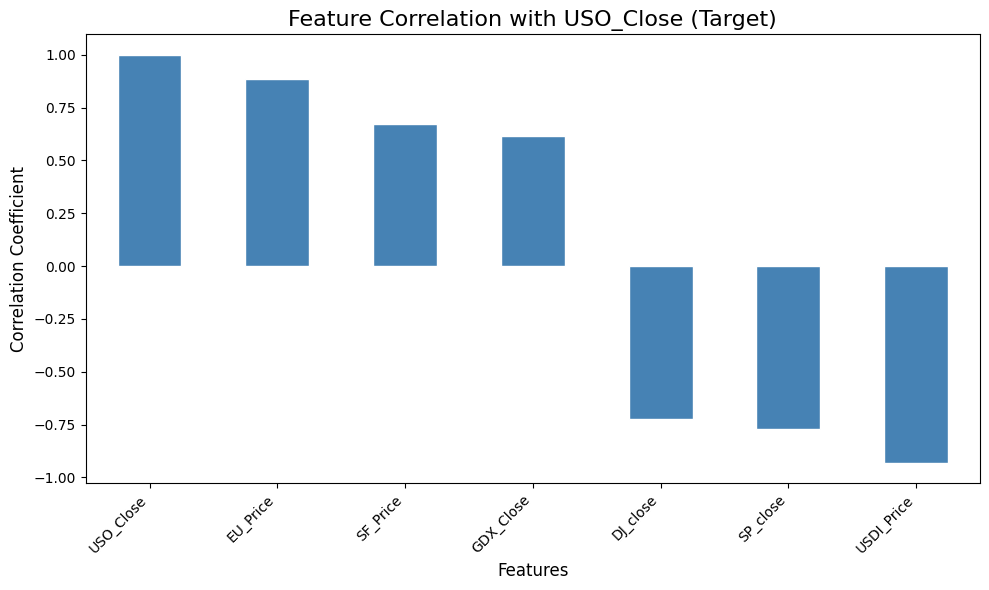

USO_Close     1.000000
EU_Price      0.887218
SF_Price      0.671612
GDX_Close     0.614915
DJ_close     -0.721378
SP_close     -0.773159
USDI_Price   -0.930767
dtype: float64


In [88]:
# Calculate correlation matrix (using a subset of features for clarity)
# Let's pick the most relevant features
# Define the key features we want to examine
key_features = ['SP_close', 'DJ_close', 'EU_Price', 'GDX_Close',
                'SF_Price', 'USDI_Price', 'USO_Close']

# Get correlation of each feature with our target USO_Close
corr_with_target = df[key_features].corrwith(df['USO_Close']).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
corr_with_target.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Correlation with USO_Close (Target)', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_with_target.png', dpi=150)
plt.show()

print(corr_with_target)

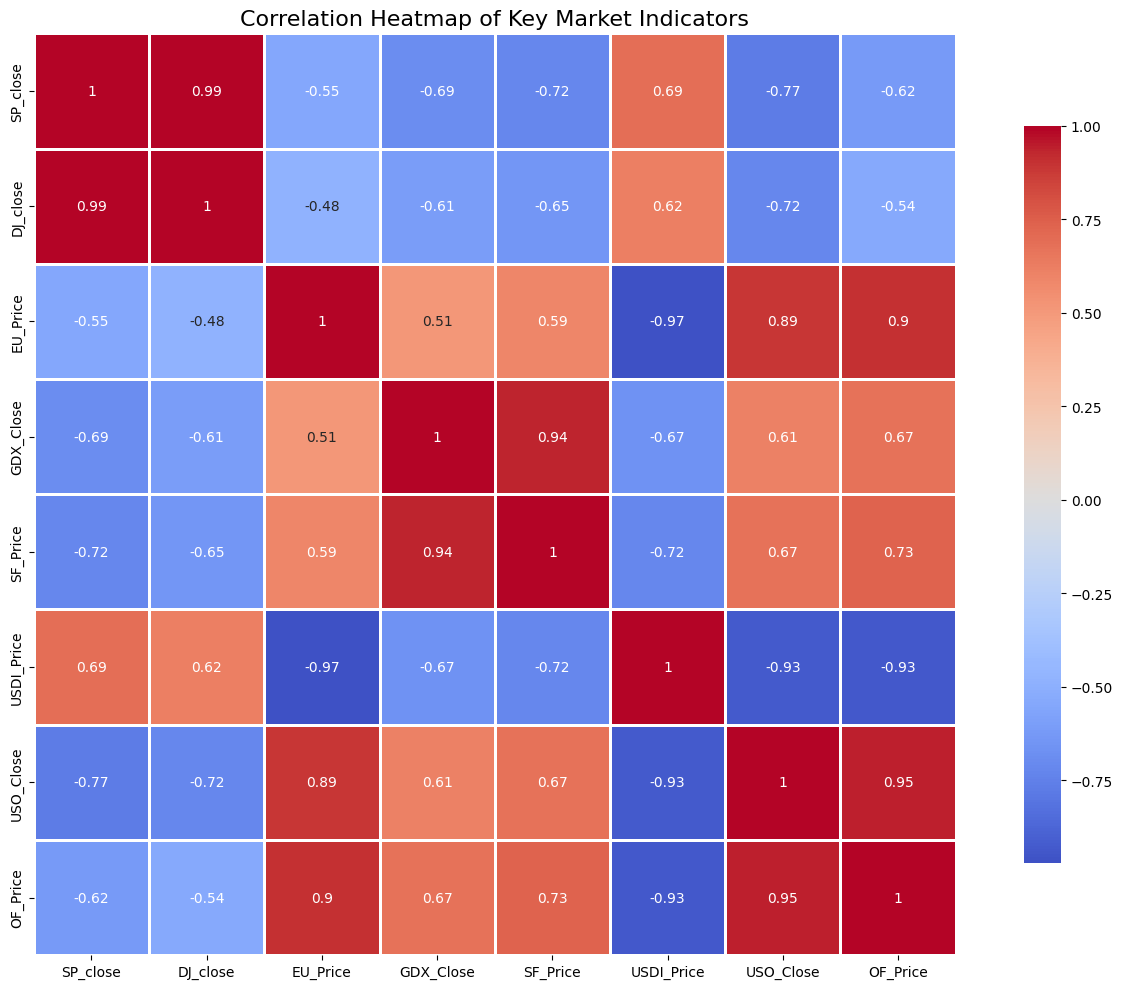

In [89]:
# Full correlation heatmap of key market indicators
plt.figure(figsize=(14, 10))

selected_features = ['SP_close', 'DJ_close', 'EU_Price', 'GDX_Close',
                     'SF_Price', 'USDI_Price', 'USO_Close', 'OF_Price']
corr_matrix = df[selected_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Key Market Indicators', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

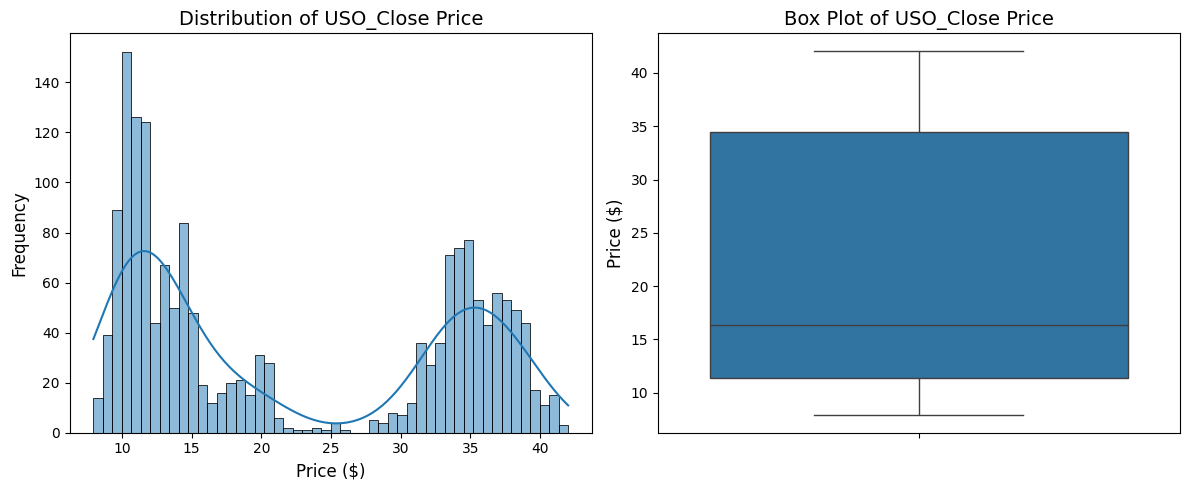

In [90]:
# Figure 2: Distribution of Target Variable
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['USO_Close'], bins=50, kde=True)
plt.title('Distribution of USO_Close Price', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(y=df['USO_Close'])
plt.title('Box Plot of USO_Close Price', fontsize=14)
plt.ylabel('Price ($)', fontsize=12)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()

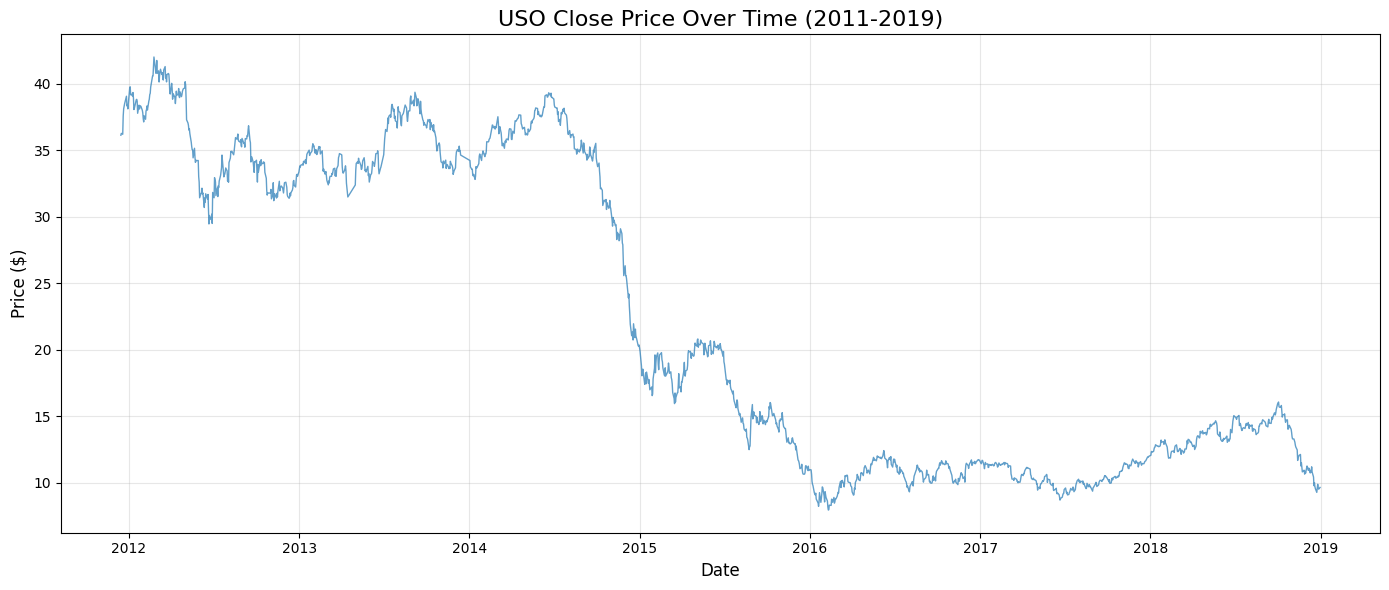

In [91]:
# Figure 3: Time Series Plot (showing trend over time)
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['USO_Close'], linewidth=1, alpha=0.7)
plt.title('USO Close Price Over Time (2011-2019)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('time_series.png', dpi=150)
plt.show()

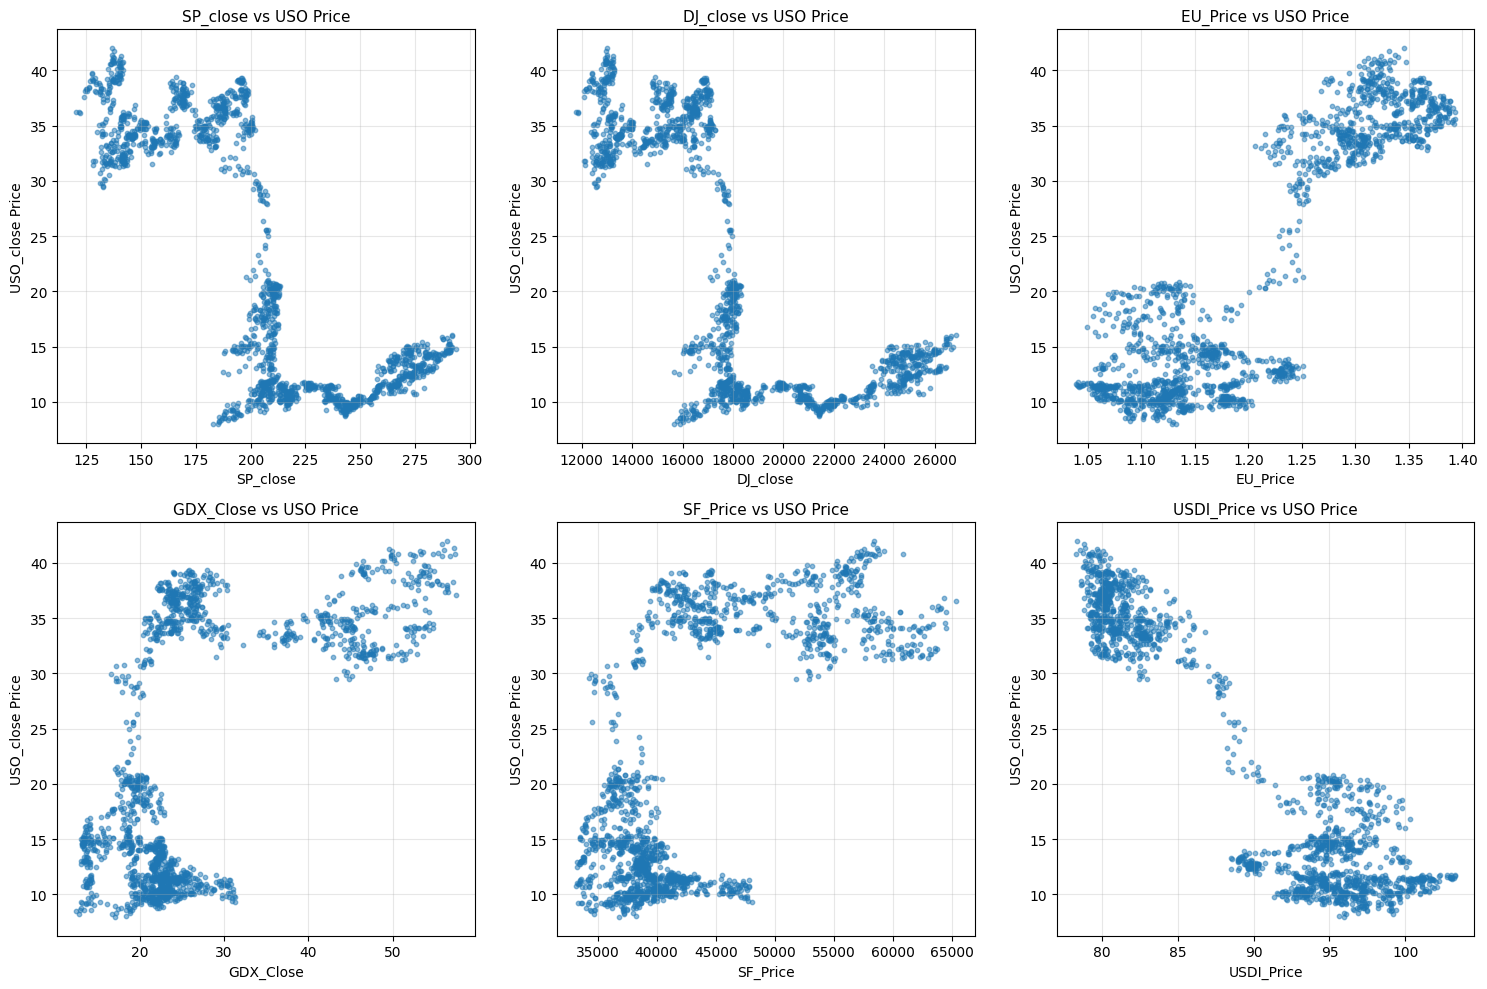

In [92]:
# Figure 4: Relationship between key features and target
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['SP_close', 'DJ_close', 'EU_Price', 'GDX_Close', 'SF_Price', 'USDI_Price']

for i, feature in enumerate(features_to_plot):
    row, col = i // 3, i % 3
    axes[row, col].scatter(df[feature], df['USO_Close'], alpha=0.5, s=10)
    axes[row, col].set_xlabel(feature, fontsize=10)
    axes[row, col].set_ylabel('USO_close Price', fontsize=10)
    axes[row, col].set_title(f'{feature} vs USO Price', fontsize=11)
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_relationships.png', dpi=150)
plt.show()

### Step 6: Model Training and Comparison


In [93]:
# initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Store results
results = {}

# Train and evaluate each model (USING SCALED DATA)
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train the model on SCALED training data
    model.fit(X_train_scaled, y_train)

    # Make predictions using SCALED data
    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)

    # Calculate metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)

    # Store results
    results[name] = {
        'train_mse': train_mse,
        'val_mse': val_mse,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'train_mae': train_mae,
        'val_mae': val_mae,
        'model': model
    }

    print(f"Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}")
    print(f"Train R2: {train_r2:.4f}, Val R2: {val_r2:.4f}")
    print(f"Train MAE: {train_mae:.4f}, Val MAE: {val_mae:.4f}")




Training Linear Regression...
Train MSE: 0.2410, Val MSE: 0.3080
Train R2: 0.9981, Val R2: 0.9977
Train MAE: 0.3940, Val MAE: 0.4491

Training Decision Tree...
Train MSE: 0.0000, Val MSE: 0.1746
Train R2: 1.0000, Val R2: 0.9987
Train MAE: 0.0000, Val MAE: 0.2704

Training Random Forest...
Train MSE: 0.0158, Val MSE: 0.0784
Train R2: 0.9999, Val R2: 0.9994
Train MAE: 0.0739, Val MAE: 0.1967


In [94]:
# comparing results visually
results_df = pd.DataFrame({
    name: {
        'Train MSE': results[name]['train_mse'],
        'Val MSE': results[name]['val_mse'],
        'Train R2': results[name]['train_r2'],
        'Val R2': results[name]['val_r2']
    } for name in models.keys()
}).T

print("\nModel Comparison:")
print(results_df)


Model Comparison:
                      Train MSE   Val MSE  Train R2    Val R2
Linear Regression  2.410466e-01  0.307985  0.998142  0.997694
Decision Tree      6.889615e-33  0.174585  1.000000  0.998693
Random Forest      1.584672e-02  0.078362  0.999878  0.999413


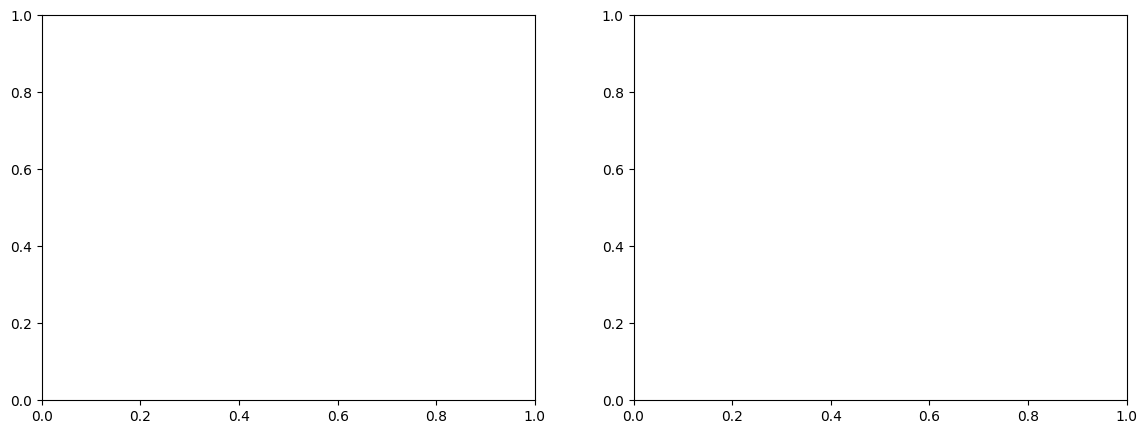

In [95]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [96]:
# MSE comparison
results_df[['Train MSE', 'Val MSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Mean Squared Error Comparison', fontsize=14)
axes[0].set_ylabel('MSE')
axes[0].set_xlabel('Model')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

In [97]:
# R2 comparison
results_df[['Train R2', 'Val R2']].plot(kind='bar', ax=axes[1])
axes[1].set_title('R² Score Comparison', fontsize=14)
axes[1].set_ylabel('R² Score')
axes[1].set_xlabel('Model')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

In [98]:
# Gradient Descent Linear Regression (SGDRegressor)
# SGDRegressor = Linear Regression trained with Stochastic Gradient Descent.
# We train epoch by epoch so we can record the loss at each step.

N_EPOCHS = 200
train_losses = []
val_losses   = []

sgd_model = SGDRegressor(
    max_iter=1,              # one epoch per .fit() call
    tol=None,                # disable automatic stopping
    warm_start=True,         # keep weights between .fit() calls
    learning_rate='constant',
    eta0=0.001,              # step size
    random_state=42
)

for epoch in range(N_EPOCHS):
    sgd_model.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd_model.predict(X_train_scaled)))
    val_losses.append(mean_squared_error(y_val,   sgd_model.predict(X_val_scaled)))

print(f"SGD Linear Regression trained for {N_EPOCHS} epochs")
print(f"Starting train MSE: {train_losses[0]:.4f}")
print(f"Final   train MSE: {train_losses[-1]:.4f}")
print(f"Final   val   MSE: {val_losses[-1]:.4f}")
print(f"Final   val   R2 : {r2_score(y_val, sgd_model.predict(X_val_scaled)):.4f}")

SGD Linear Regression trained for 200 epochs
Starting train MSE: 32.1484
Final   train MSE: 0.2770
Final   val   MSE: 0.3354
Final   val   R2 : 0.9975


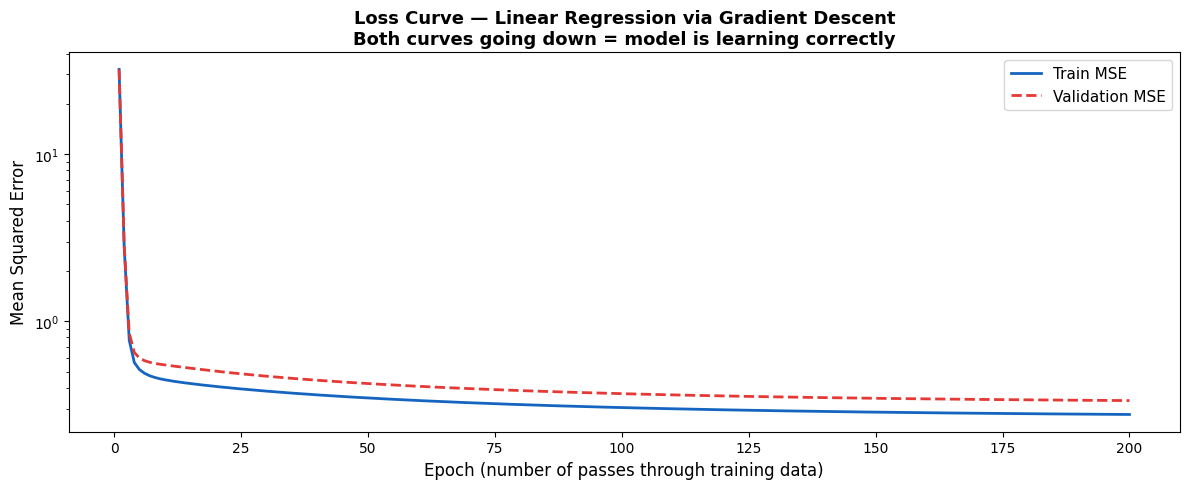

In [99]:
# Plot the Loss Curve
# This shows how the model's error reduced with each epoch of gradient descent
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(range(1, N_EPOCHS + 1), train_losses,
        label='Train MSE', color='#1565C0', linewidth=2)
ax.plot(range(1, N_EPOCHS + 1), val_losses,
        label='Validation MSE', color='#E53935', linewidth=2, linestyle='--')

ax.set_xlabel('Epoch (number of passes through training data)', fontsize=12)
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title('Loss Curve — Linear Regression via Gradient Descent\n'
             'Both curves going down = model is learning correctly', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_yscale('log')   # log scale makes the convergence easier to see
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

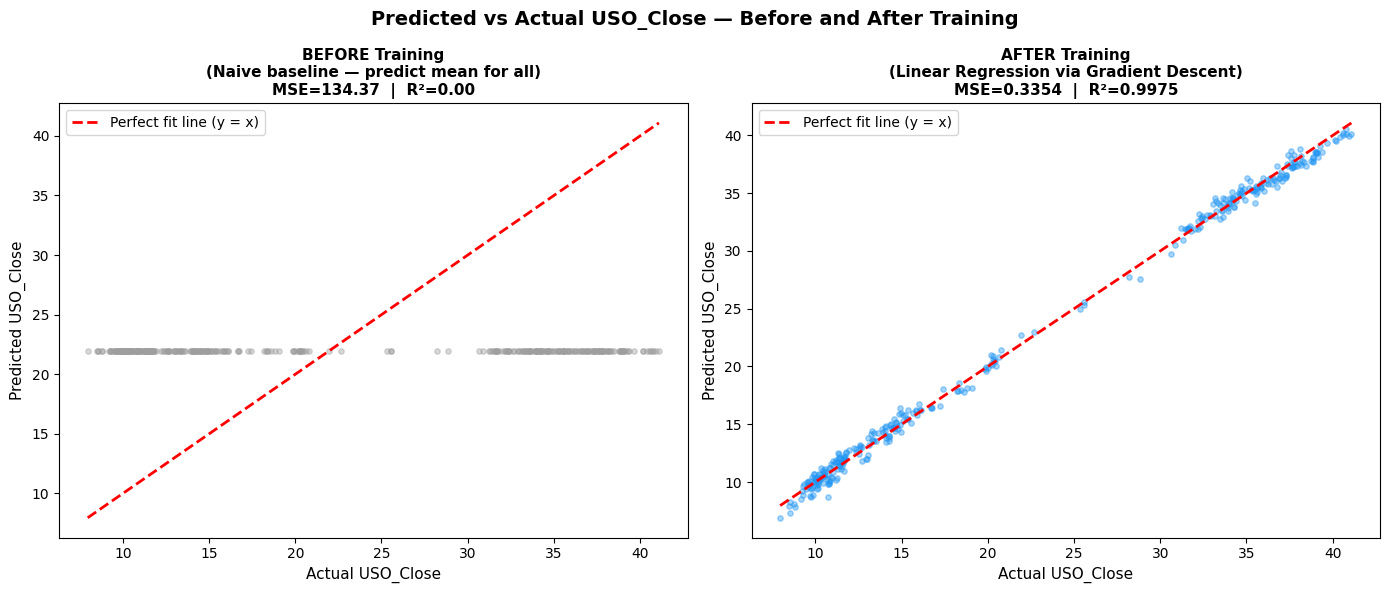

In [100]:
# Scatter Plot: Before and After Training
# BEFORE = naive baseline (predict training mean for everyone, R²=0)
# AFTER  = trained SGD model predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# BEFORE
naive_pred = np.full(len(y_val), y_train.mean())
axes[0].scatter(y_val, naive_pred, alpha=0.4, s=15, color='#9E9E9E')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
             'r--', linewidth=2, label='Perfect fit line (y = x)')
axes[0].set_xlabel('Actual USO_Close', fontsize=11)
axes[0].set_ylabel('Predicted USO_Close', fontsize=11)
axes[0].set_title(f'BEFORE Training\n(Naive baseline — predict mean for all)\n'
                  f'MSE={mean_squared_error(y_val, naive_pred):.2f}  |  R²=0.00',
                  fontsize=11, fontweight='bold')
axes[0].legend()

# AFTER
sgd_val_pred = sgd_model.predict(X_val_scaled)
sgd_mse = mean_squared_error(y_val, sgd_val_pred)
sgd_r2  = r2_score(y_val, sgd_val_pred)
axes[1].scatter(y_val, sgd_val_pred, alpha=0.4, s=15, color='#2196F3')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
             'r--', linewidth=2, label='Perfect fit line (y = x)')
axes[1].set_xlabel('Actual USO_Close', fontsize=11)
axes[1].set_ylabel('Predicted USO_Close', fontsize=11)
axes[1].set_title(f'AFTER Training\n(Linear Regression via Gradient Descent)\n'
                  f'MSE={sgd_mse:.4f}  |  R²={sgd_r2:.4f}',
                  fontsize=11, fontweight='bold')
axes[1].legend()

plt.suptitle('Predicted vs Actual USO_Close — Before and After Training',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

In [101]:
# Saving the best performing model and the scaler
# joblib saves the trained object to disk so the API can load it later

best_model_name = results_df.sort_values('Val MSE').index[0]
model_map = {
    'Linear Regression': models['Linear Regression'],
    'Decision Tree':     models['Decision Tree'],
    'Random Forest':     models['Random Forest']
}
best_model = model_map[best_model_name]

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')

print(f"Best model : {best_model_name}")
print(f"Saved      : best_model.pkl")
print(f"Saved      : scaler.pkl")

Best model : Random Forest
Saved      : best_model.pkl
Saved      : scaler.pkl


In [102]:
# Prediction function
def predict_uso_close(feature_dict: dict) -> float:
    """
    Predict the USO_Close price given a dictionary of feature values.
    Keys must match the 63 feature columns used during training.
    Returns the predicted price in USD.
    """
    loaded_model  = joblib.load('best_model.pkl')
    loaded_scaler = joblib.load('scaler.pkl')

    # Arrange features in the exact order the model was trained on
    input_array  = np.array([[feature_dict[f] for f in feature_columns]])
    input_scaled = loaded_scaler.transform(input_array)
    prediction   = loaded_model.predict(input_scaled)[0]
    return round(float(prediction), 4)


# Test it on one real row from the validation set
sample    = X_val.iloc[0].to_dict()
actual    = float(y_val.iloc[0])
predicted = predict_uso_close(sample)

print("Test prediction on one real validation row:")
print(f"  Actual    USO_Close : ${actual:.4f}")
print(f"  Predicted USO_Close : ${predicted:.4f}")
print(f"  Error               : ${abs(actual - predicted):.4f}")
print()
print(f"The API (Task 2) will expect these {len(feature_columns)} features:")
for i, col in enumerate(feature_columns):
    print(f"  {i+1:2d}. {col}")

Test prediction on one real validation row:
  Actual    USO_Close : $38.8600
  Predicted USO_Close : $38.5517
  Error               : $0.3083

The API (Task 2) will expect these 63 features:
   1. SP_open
   2. SP_high
   3. SP_low
   4. SP_close
   5. SP_Ajclose
   6. SP_volume
   7. DJ_open
   8. DJ_high
   9. DJ_low
  10. DJ_close
  11. DJ_Ajclose
  12. DJ_volume
  13. EG_open
  14. EG_high
  15. EG_low
  16. EG_close
  17. EG_Ajclose
  18. EG_volume
  19. EU_Price
  20. EU_open
  21. EU_high
  22. EU_low
  23. OF_Price
  24. OF_Open
  25. OF_High
  26. OF_Low
  27. OF_Volume
  28. OS_Price
  29. OS_Open
  30. OS_High
  31. OS_Low
  32. SF_Price
  33. SF_Open
  34. SF_High
  35. SF_Low
  36. SF_Volume
  37. USB_Price
  38. USB_Open
  39. USB_High
  40. USB_Low
  41. PLT_Price
  42. PLT_Open
  43. PLT_High
  44. PLT_Low
  45. PLD_Price
  46. PLD_Open
  47. PLD_High
  48. PLD_Low
  49. RHO_PRICE
  50. USDI_Price
  51. USDI_Open
  52. USDI_High
  53. USDI_Low
  54. USDI_Volume
  55. GD

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
